In [1]:
import numpy as np
import numpy.typing as npt

# from qiskit.circuit.controlflow import BreakLoopOp, ForLoopOp
from qiskit import transpile
from qiskit.circuit import (
    BreakLoopOp,
    ClassicalRegister,
    ForLoopOp,
    QuantumCircuit,
    QuantumRegister,
)
from qiskit.circuit.library import BlueprintCircuit
from qiskit.quantum_info import Statevector, partial_trace, state_fidelity
from qiskit_aer_encore.simulator import generate_aer_simulator
from qiskit_encore.quantum_state import (
    IdealPreparableStatevector,
    PreparableStatevector,
)
from qiskit_phase_propagator.sample_based import (
    GenericIterativeSampleBasedPhasePropagator,
)

ModuleNotFoundError: No module named 'qiskit_encore.quantum_state'

In [ ]:
n = 3
phi = IdealPreparableStatevector([1, 0, 0, 1, 1, 0, 1, 1], normalize=True)
psi = IdealPreparableStatevector([1, 1, 1, 1, 1, 1, 1, 1], normalize=True)
deltas = [0.1, 0.2, 0.3]

In [ ]:
propagator = GenericIterativeSampleBasedPhasePropagator.from_state(
    phi,
    deltas,
)
# propagator.draw("mpl")

: 

In [ ]:
psi_reg = QuantumRegister(n, name=r"\psi")
phi_reg = QuantumRegister(n, name=r"\phi")
success_flag = ClassicalRegister(n, name="success_flag")

circuit = QuantumCircuit(psi_reg, phi_reg, success_flag)
circuit.initialize(psi.data.tolist(), psi_reg)
circuit.compose(propagator, circuit.qubits, circuit.clbits, inplace=True)
circuit.save_statevector()  # type: ignore

simulator = generate_aer_simulator()
transpiled = transpile(circuit, simulator)
job = simulator.run(transpiled, shots=1)
result = job.result()
counts = result.get_counts(circuit)
output_state_full = result.get_statevector(circuit)

traced = partial_trace(
    output_state_full,
    np.arange(phi.num_qubits, 2 * phi.num_qubits).tolist(),
)
output_state = traced.to_statevector()

alpha = np.sum(deltas)

expected_output = np.exp(1j * alpha * np.abs(phi.data) ** 2) * psi.data

In [ ]:
counts
# check if all measured qubits are 0
all(int(key, 2) < 2 ** (n - 1) for key in counts.keys())

True

In [ ]:
counts.int_outcomes()

{0: 1}

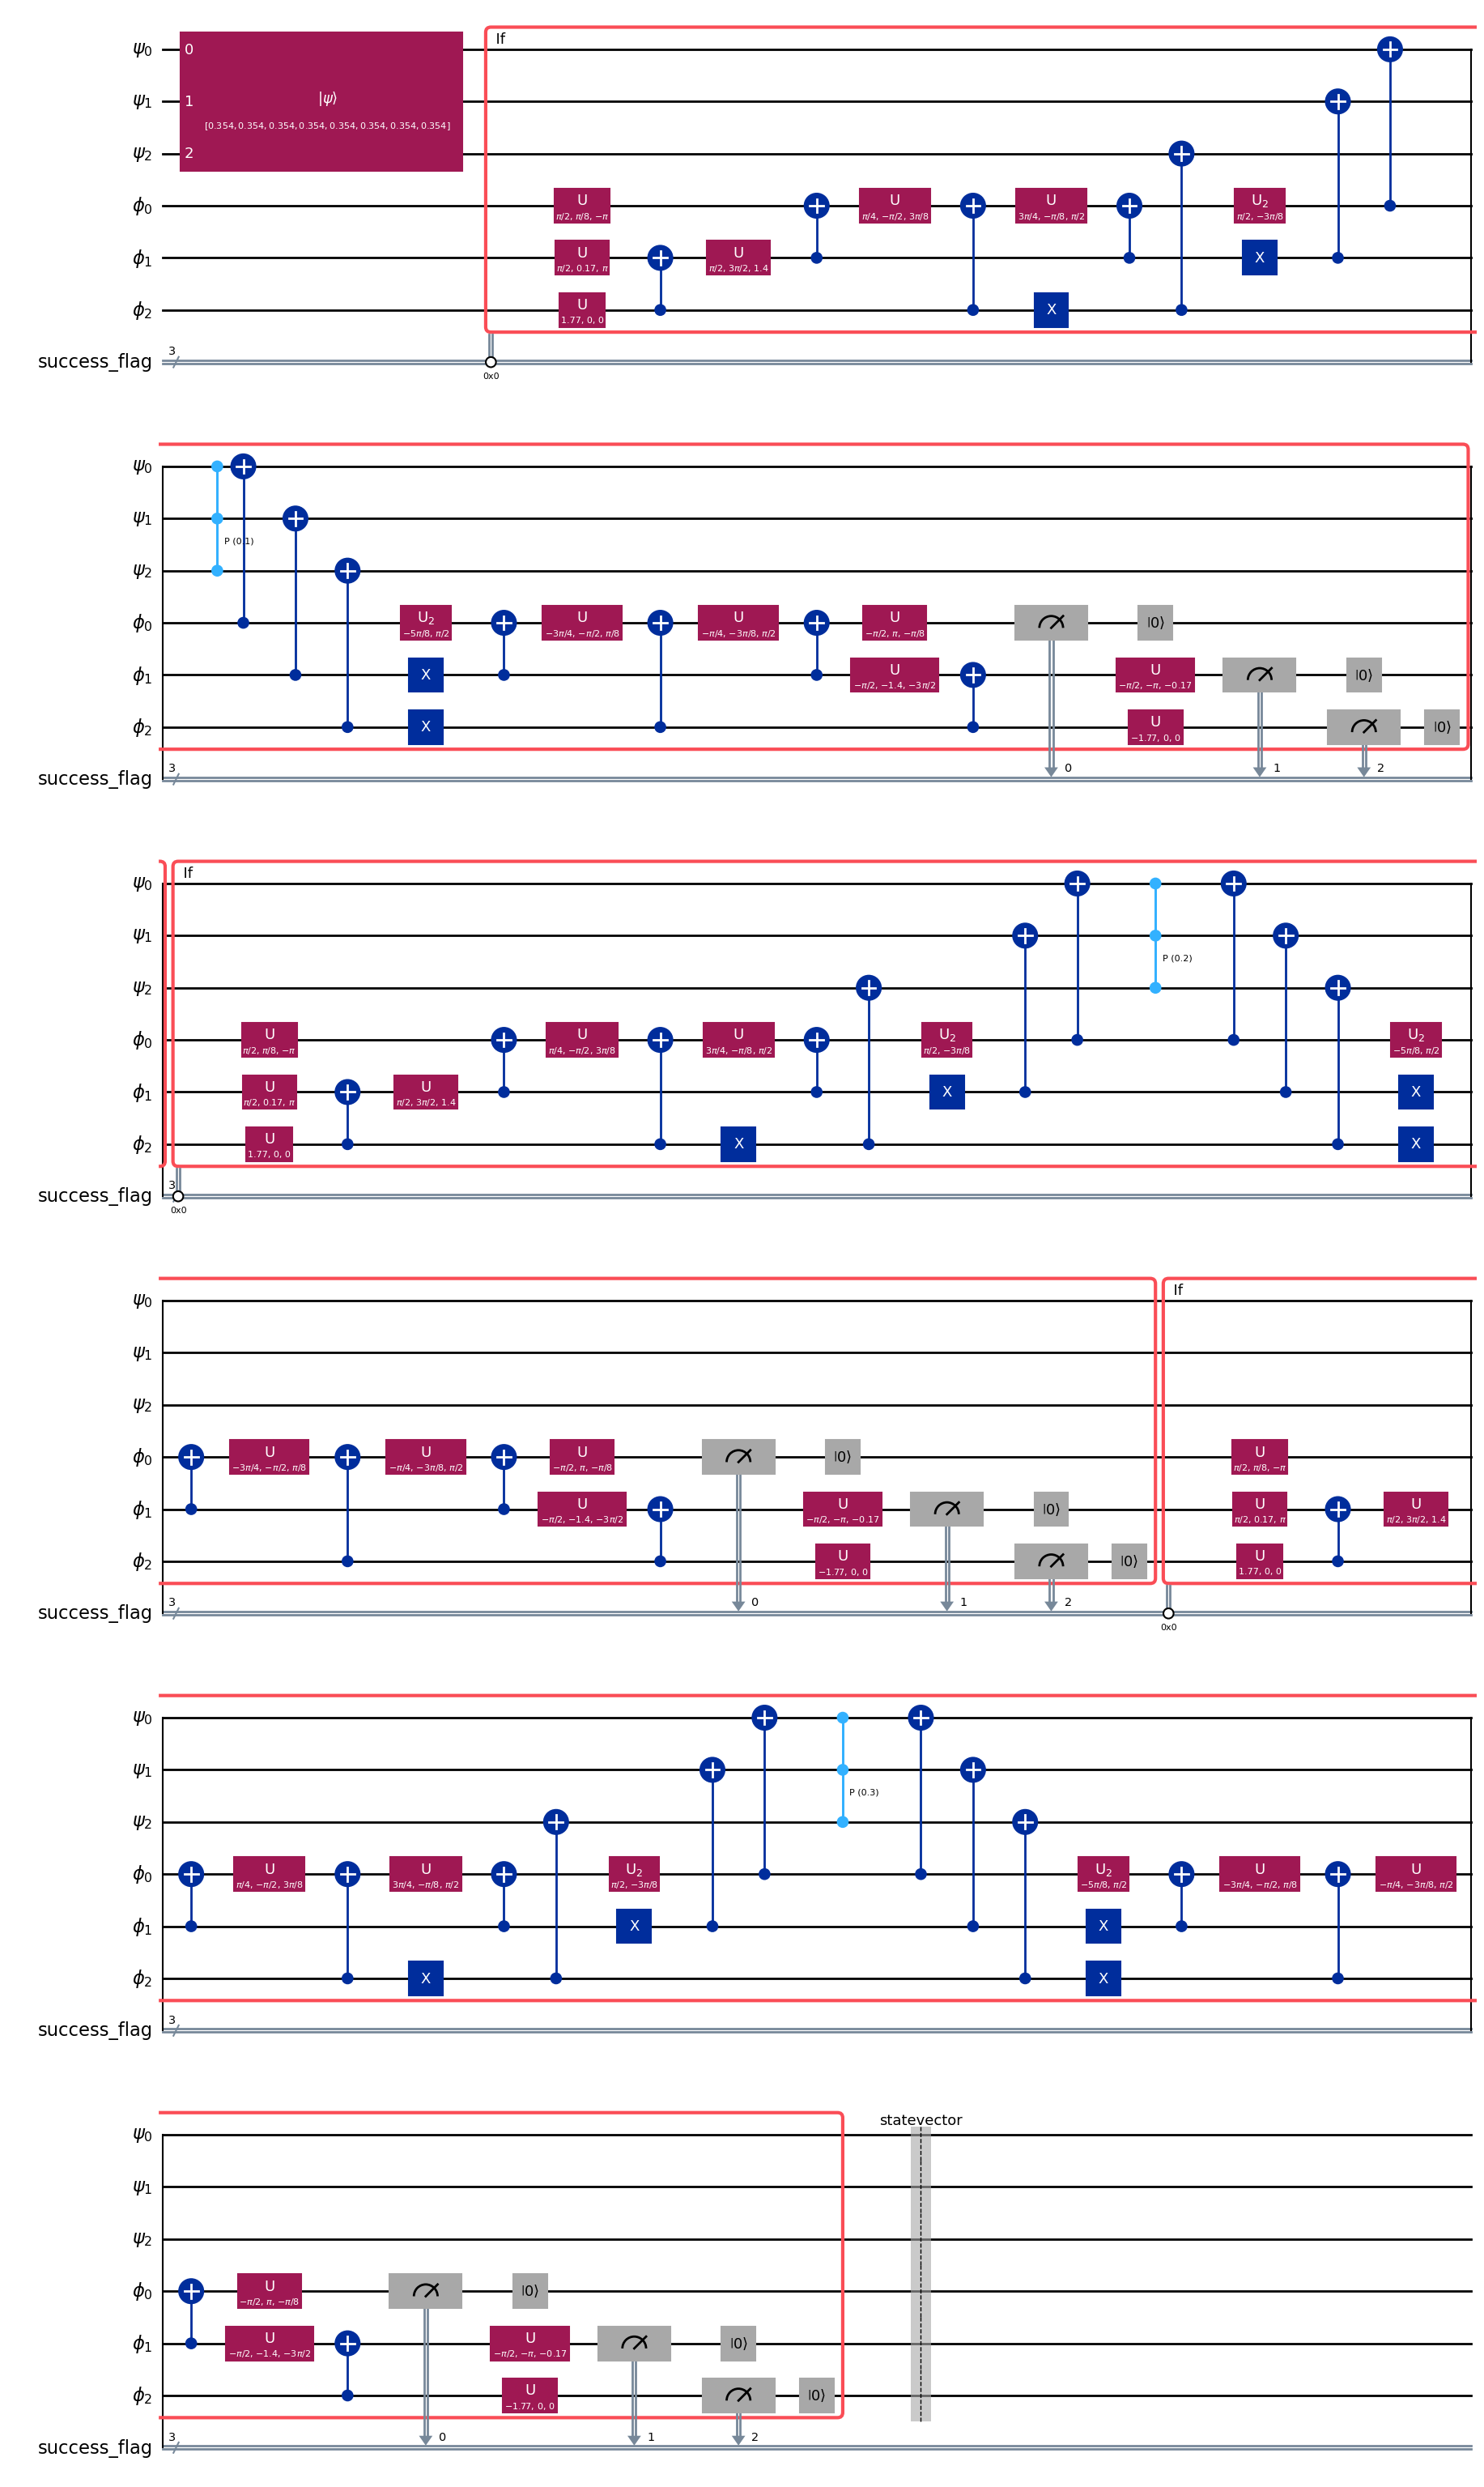

In [ ]:
transpiled.draw("mpl")

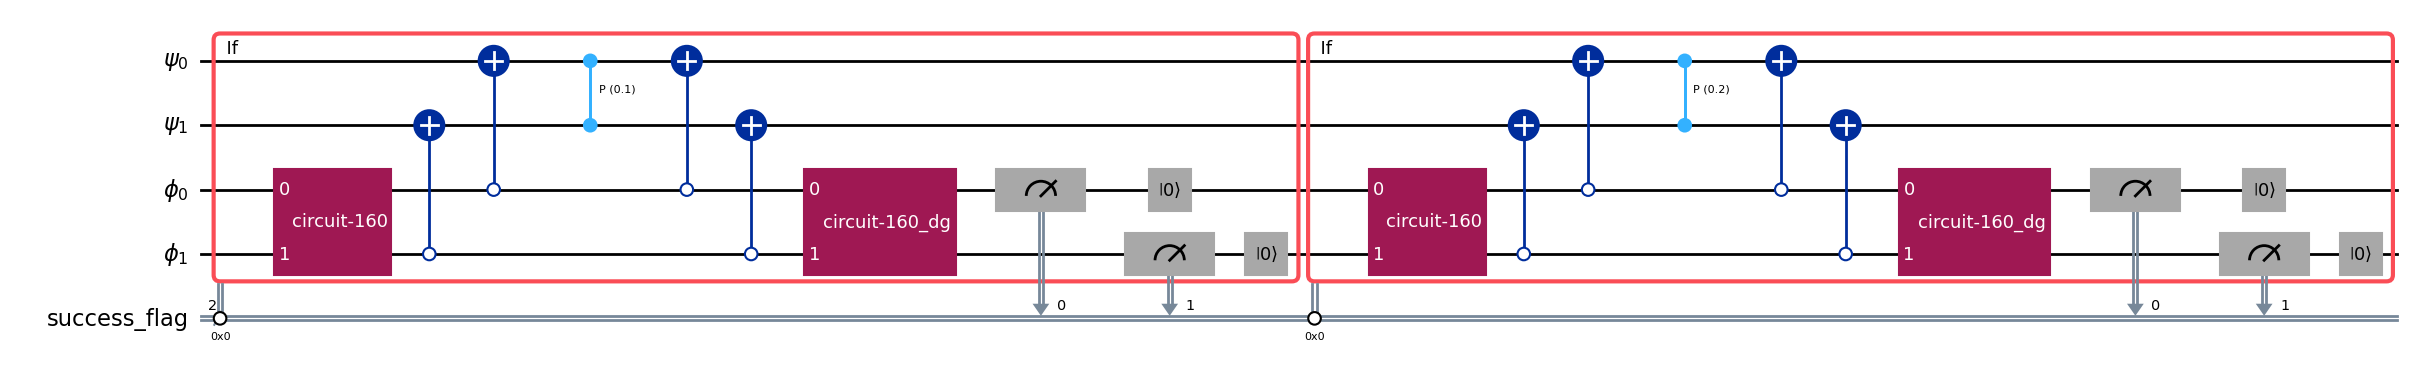

In [ ]:
# class GenericPhasePropagator(BlueprintCircuit):
#     """A generic phase propagator."""

#     def __init__(self, num_qubits: int) -> None:
#         """Create a new blueprint circuit."""
#         super().__init__(name="Generic Phase Propagator")

#     def _check_configuration(self, raise_on_failure: bool = True) -> bool:
#         return False

#     def _build(self) -> None:
#         if self._is_built:
#             return

#         # check whether the configuration is valid
#         self._check_configuration()

#         # build the circuit

#         # mark the circuit as built
#         self._is_built = True


def generate_phase_propagator_circuit(
    phi: PreparableStatevector, deltas: npt.NDArray | list[float]
) -> QuantumCircuit:
    n = phi.num_qubits

    # The initializer operator for the |phi> state
    U_phi, U_phi_dagger = phi.initializer_gate, phi.de_initializer_gate

    number_of_cycles = len(deltas)

    psi_reg = QuantumRegister(n, name=r"\psi")
    phi_reg = QuantumRegister(n, name=r"\phi")
    success_flag = ClassicalRegister(n, name="success_flag")
    circuit = QuantumCircuit(psi_reg, phi_reg, success_flag)
    circuit.name = "Iterative phase propagator"

    for r in range(number_of_cycles):
        with circuit.if_test((success_flag, 0)) as else_:
            delta = deltas[r]

            # Step 1: initializing the |phi> register
            circuit.append(U_phi, phi_reg)

            # Step 2: the partial phase operator
            # Flag qubit computation
            for i in range(psi_reg.size):
                circuit.cx(
                    phi_reg[psi_reg.size - 1 - i],
                    psi_reg[psi_reg.size - 1 - i],
                    ctrl_state=0,
                )

            # The application of the phase
            circuit.mcp(delta, psi_reg[0:-1], psi_reg[-1])

            # "Un-computing" the flag qubits
            for i in range(psi_reg.size):
                circuit.cx(phi_reg[i], psi_reg[i], ctrl_state=0)

            # Step 3: partial measurement of the secondary register
            circuit.append(U_phi_dagger, phi_reg)
            circuit.measure(phi_reg, success_flag)

            # Reset the secondary state to |0> after the Step 3 (partial measurement) of the previous cycle. We expect the result of the measurement to almost always be 0 and if it is not, the protocol has failed. Therefore, this resetting in not strictly required but we are doing it to still see the corrupt output even though an error occurs.
            circuit.reset(phi_reg)

            # Take a snapshot of the wavefunction at this point
            # circuit.save_statevector(f"{r}") # type: ignore

        # with else_:
        #     circuit.metadata["failed_at_cycle"] = r

        # circuit.metadata = {
        #     "num_of_cycles": number_of_cycles,
        #     "n": n,
        #     "deltas": deltas,
        #     "phi_normalized": phi,
        # }

    return circuit


generate_phase_propagator_circuit(
    IdealPreparableStatevector([1, 0, 0, 1], normalize=True), [0.1, 0.2]
).draw("mpl", fold=-1)

In [ ]:
from qiskit_hamiltonian_simulation.time_independent import (
    MomentumDomainEvolutionSampleBased,
    PositionDomainEvolutionSampleBased,
)

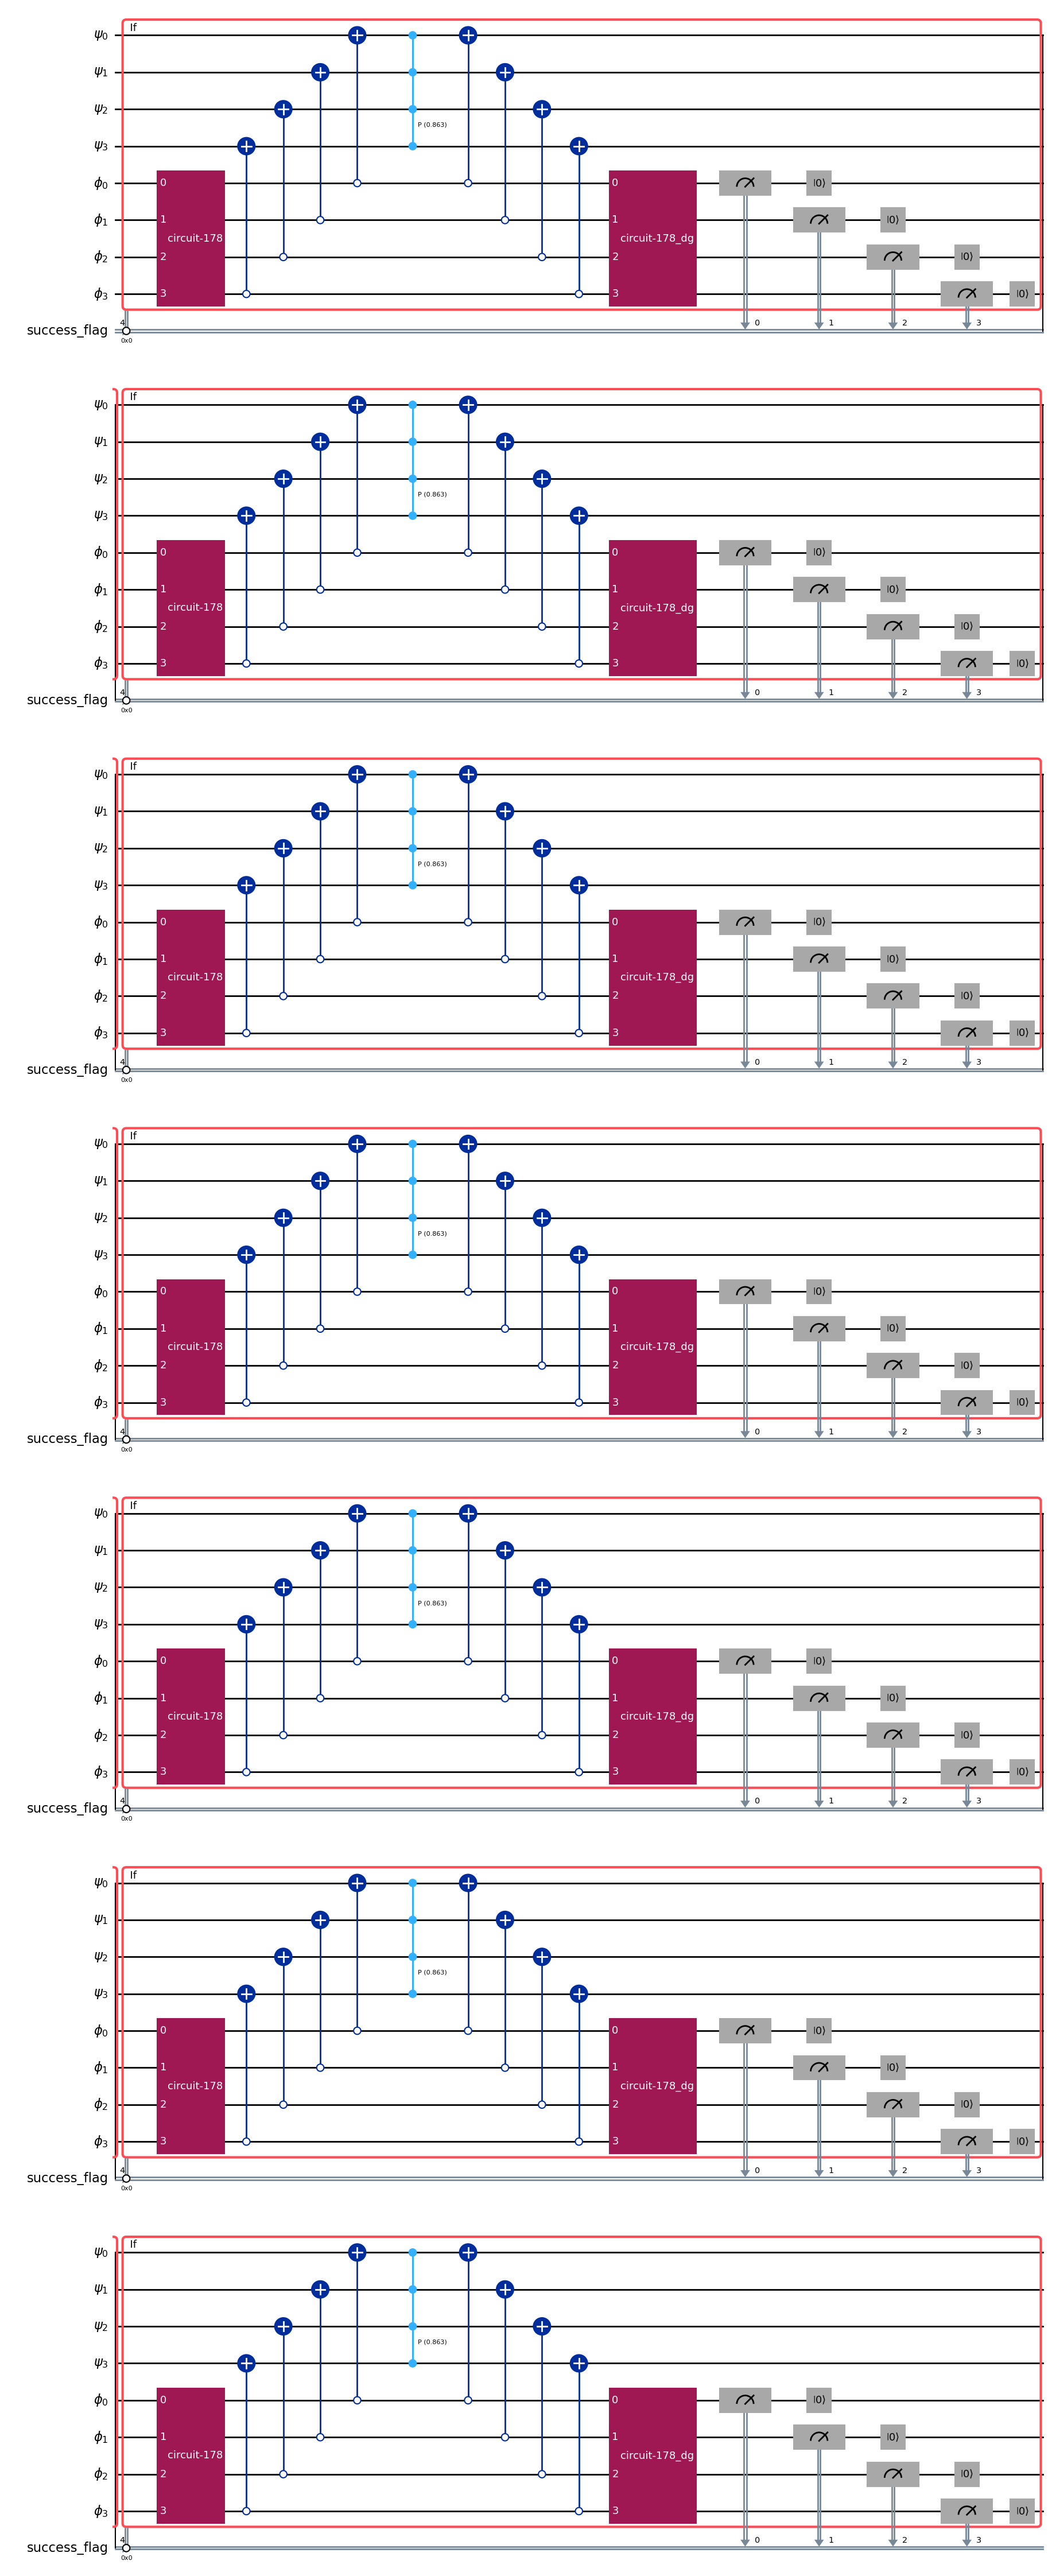

In [ ]:
PositionDomainEvolutionSampleBased(
    f_of_x=lambda x: x**2, x=np.linspace(-1, 1, 16), max_delta=1
).draw("mpl")